<a href="https://colab.research.google.com/github/Somya456/Image-Segmentation-for-Disaster-Resilience/blob/main/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import albumentations as A
import random
import matplotlib.pyplot as plt


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"
X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "Y_train.npy"))

print("Original Training Images :", X_train.shape)
print("Original Training Masks  :", Y_train.shape)

Original Training Images : (2720, 256, 256, 3)
Original Training Masks  : (2720, 256, 256, 1)


In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Rotate(
        limit=20,
        border_mode=0,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    )
])

In [ ]:
aug_images = []
aug_masks = []

for image, mask in zip(X_train, Y_train):

    augmented = transform(
        image=image,
        mask=mask
    )

    aug_image = augmented["image"]

    aug_mask = augmented["mask"]

    # Keep mask binary
    aug_mask = (aug_mask > 0.5).astype(np.uint8)

    aug_images.append(aug_image)
    aug_masks.append(aug_mask)

In [ ]:
aug_images = np.array(
    aug_images,
    dtype=np.float32
)

aug_masks = np.array(
    aug_masks,
    dtype=np.uint8
)

print("Augmented Images :", aug_images.shape)
print("Augmented Masks  :", aug_masks.shape)


Augmented Images : (2720, 256, 256, 3)
Augmented Masks  : (2720, 256, 256, 1)


In [ ]:
X_train_aug = np.concatenate(
    [X_train, aug_images],
    axis=0
)

Y_train_aug = np.concatenate(
    [Y_train, aug_masks],
    axis=0
)

print("\nFinal Training Dataset")

print("Images :", X_train_aug.shape)
print("Masks  :", Y_train_aug.shape)


Final Training Dataset
Images : (5440, 256, 256, 3)
Masks  : (5440, 256, 256, 1)


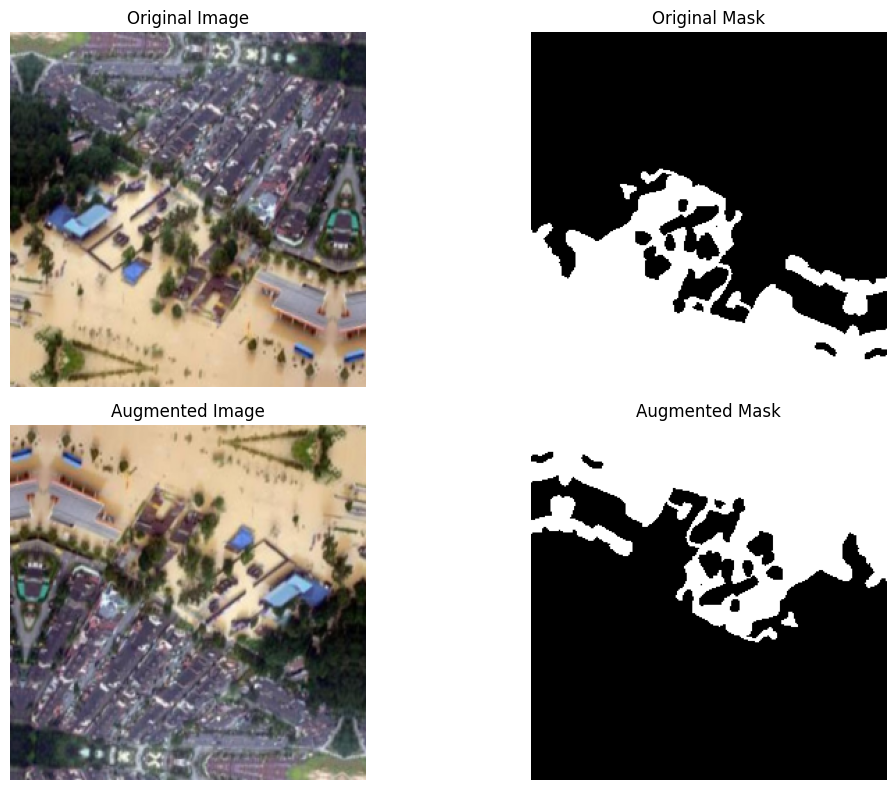

In [ ]:
index = random.randint(0, len(X_train)-1)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(X_train[index])
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(Y_train[index].squeeze(), cmap="gray")
plt.title("Original Mask")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(aug_images[index])
plt.title("Augmented Image")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(aug_masks[index].squeeze(), cmap="gray")
plt.title("Augmented Mask")
plt.axis("off")

plt.tight_layout()
plt.show()